# Análise de Clustering com K-Means - PIB dos Municípios Brasileiros

Este notebook implementa o algoritmo de clustering K-Means para analisar dados do PIB (Produto Interno Bruto) dos municípios brasileiros. O objetivo é agrupar municípios com características econômicas semelhantes.

## 1. Importação de Bibliotecas

Nesta etapa, importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do algoritmo K-Means.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 2. Carregamento e Exploração Inicial dos Dados

Carregamos o arquivo CSV contendo dados do PIB dos municípios brasileiros e realizamos uma exploração inicial para entender a estrutura do dataset.

In [77]:
# Carregar o dataset
df = pd.read_csv('br_ibge_pib_municipio.csv')

# Exibir as primeiras linhas
print("Primeiras linhas do dataset:")
df.head()

Primeiras linhas do dataset:


,id_municipio,ano,pib,impostos_liquidos,va,va_agropecuaria,va_industria,va_servicos,va_adespss
0,1100403,2002,45060000,3219000.0,41841000.0,9171000.0,1992000.0,8865000.0,21813000.0
1,1101005,2002,43979000,1689000.0,42290000.0,12082000.0,1718000.0,4590000.0,23899000.0
2,1200336,2002,31111000,365000.0,30746000.0,4954000.0,1462000.0,4100000.0,20230000.0
3,1200385,2002,54088000,916000.0,53172000.0,17208000.0,2609000.0,6527000.0,26827000.0
4,1301654,2002,26050000,676000.0,25374000.0,7184000.0,864000.0,2598000.0,14728000.0


In [78]:
# Informações sobre o dataset
print("\nInformações do dataset:")
df.info()


Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 122466 entries, 0 to 122465
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_municipio       122466 non-null  int64  
 1   ano                122466 non-null  int64  
 2   pib                122466 non-null  int64  
 3   impostos_liquidos  111326 non-null  float64
 4   va                 111326 non-null  float64
 5   va_agropecuaria    111326 non-null  float64
 6   va_industria       111326 non-null  float64
 7   va_servicos        111326 non-null  float64
 8   va_adespss         111326 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 8.4 MB


In [79]:
# Estatísticas descritivas
print("\nEstatísticas descritivas:")
df.describe()


Estatísticas descritivas:


,id_municipio,ano,pib,impostos_liquidos,va,va_agropecuaria,va_industria,va_servicos,va_adespss
count,1.224660e+05,122466.000000,1.224660e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05
mean,3.253274e+06,2012.503830,9.307385e+08,1.194854e+08,7.155468e+08,4.016657e+07,1.738817e+08,3.817421e+08,1.197564e+08
std,9.845391e+05,6.343832,9.909266e+09,1.646866e+09,7.356382e+09,9.218991e+07,1.208217e+09,5.492226e+09,1.213122e+09
min,1.100015e+06,2002.000000,-1.904600e+07,-1.508800e+07,-5.105930e+08,-2.299000e+06,-2.897193e+09,3.720000e+05,1.447000e+06
25%,2.512101e+06,2007.000000,4.781925e+07,1.703000e+06,4.201100e+07,6.707250e+06,2.183000e+06,1.005800e+07,1.456100e+07
50%,3.146255e+06,2013.000000,1.150230e+08,5.309000e+06,9.778250e+07,1.691200e+07,7.302000e+06,2.749800e+07,2.945600e+07
75%,4.119103e+06,2018.000000,3.352805e+08,2.162750e+07,2.754320e+08,4.057250e+07,4.085025e+07,9.431575e+07,6.852600e+07
max,5.300108e+06,2023.000000,1.066825e+12,1.681840e+11,6.607967e+11,5.004239e+09,6.689305e+10,5.497675e+11,1.168092e+11


In [80]:
# Verificar valores ausentes
print("\nValores ausentes por coluna:")
df.isnull().sum()


Valores ausentes por coluna:


id_municipio             0
ano                      0
pib                      0
impostos_liquidos    11140
va                   11140
va_agropecuaria      11140
va_industria         11140
va_servicos          11140
va_adespss           11140
dtype: int64

In [81]:
# Verificar anos disponíveis no dataset
print("\nAnos disponíveis no dataset:")
print(df['ano'].unique())
print(f"\nTotal de anos: {df['ano'].nunique()}")


Anos disponíveis no dataset:
[2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015
 2016 2017 2018 2019 2020 2021 2022 2023]

Total de anos: 22


## 3. Pré-processamento dos Dados

O pré-processamento é crucial para o sucesso do clustering. Realizamos as seguintes etapas:

### 3.1 Seleção de Anos para Análise

Como o dataset contém dados de múltiplos anos, selecionaremos os anos de 2023 e 2022 para a análise de clustering. Isso permite analisar os dados mais recentes disponíveis.

In [82]:
# Selecionar anos 2023 e 2022 para análise
anos_selecionados = [2023, 2022]
print(f"Anos selecionados para análise: {anos_selecionados}")

# Filtrar dados para os anos selecionados
df_ano = df[df['ano'].isin(anos_selecionados)].copy()
print(f"Número de registros nos anos {anos_selecionados}: {len(df_ano)}")
print(f"Distribuição por ano:")
print(df_ano['ano'].value_counts().sort_index())

Anos selecionados para análise: [2023, 2022]
Número de registros nos anos [2023, 2022]: 11140
Distribuição por ano:
ano
2022    5570
2023    5570
Name: count, dtype: int64


### 3.2 Seleção de Variáveis para Clustering

Selecionamos as variáveis econômicas relevantes para o clustering:
- pib: Produto Interno Bruto total
- va_agropecuaria: Valor Adicionado da Agropecuária
- va_industria: Valor Adicionado da Indústria
- va_servicos: Valor Adicionado dos Serviços
- va_adespss: Valor Adicionado de ADESPSS

In [83]:
# Selecionar variáveis para clustering
variaveis_clustering = ['pib', 'va_agropecuaria', 'va_industria', 'va_servicos', 'va_adespss']

# Criar dataframe com as variáveis selecionadas
df_clustering = df_ano[variaveis_clustering].copy()

print("Variáveis selecionadas para clustering:")
print(variaveis_clustering)
print(f"\nDimensões do dataframe de clustering: {df_clustering.shape}")

Variáveis selecionadas para clustering:
['pib', 'va_agropecuaria', 'va_industria', 'va_servicos', 'va_adespss']

Dimensões do dataframe de clustering: (11140, 5)


In [84]:
### 3.3 Tratamento de Valores Ausentes

#Verificamos e tratamos valores ausentes, se houver.

In [85]:
# Verificar o shape do dataframe antes de prosseguir
print(f"Shape de df_ano: {df_ano.shape}")
print(f"Shape de df_clustering: {df_clustering.shape}")

# Verificar se o dataframe está vazio
if df_clustering.shape[0] == 0:
    print("ERRO: O dataframe está vazio após a seleção de variáveis!")
    print("Verificando possíveis causas...")
    print(f"\nAnos disponíveis: {sorted(df['ano'].unique())}")
    print(f"Anos selecionados: {anos_selecionados}")
    print(f"Número de registros nos anos {anos_selecionados}: {len(df[df['ano'].isin(anos_selecionados)])}")
    
    # Tentar usar os anos com mais dados se os anos selecionados não tiverem dados
    if len(df[df['ano'].isin(anos_selecionados)]) == 0:
        print(f"\nOs anos {anos_selecionados} não possuem dados. Selecionando os anos com mais dados...")
        anos_com_mais_dados = df['ano'].value_counts().head(2).index.tolist()
        print(f"Novos anos selecionados: {anos_com_mais_dados}")
        df_ano = df[df['ano'].isin(anos_com_mais_dados)].copy()
        df_clustering = df_ano[variaveis_clustering].copy()
        print(f"Novo número de registros: {len(df_clustering)}")
else:
    print(f"Dataframe possui {df_clustering.shape[0]} registros. Prosseguindo com a análise.")

Shape de df_ano: (11140, 9)
Shape de df_clustering: (11140, 5)
Dataframe possui 11140 registros. Prosseguindo com a análise.


# Verificar valores ausentes no dataframe de clustering
print("Valores ausentes no dataframe de clustering:")
print(df_clustering.isnull().sum())

# Se houver valores ausentes, remover as linhas
if df_clustering.isnull().sum().sum() > 0:
    print(f"\nRemovendo linhas com valores ausentes...")
    antes = len(df_clustering)
    df_clustering = df_clustering.dropna()
    depois = len(df_clustering)
    print(f"Linhas removidas: {antes - depois}")
    print(f"Novo número de municípios: {depois}")
else:
    print("\nNão há valores ausentes no dataset.")

# Verificar se o dataframe ainda tem dados após o tratamento
if df_clustering.shape[0] == 0:
    raise ValueError("O dataframe está vazio após o tratamento de valores ausentes. Não é possível prosseguir com a análise.")

In [86]:
### 3.4 Normalização/Padronização dos Dados

##O algoritmo K-Means é sensível à escala das variáveis. Variáveis com escalas diferentes podem dominar o cálculo das distâncias. Por isso, aplicamos a padronização (StandardScaler) para que todas as variáveis tenham média 0 e desvio padrão 1.

# Criar o scaler
scaler = StandardScaler()

# Aplicar a padronização
df_scaled = scaler.fit_transform(df_clustering)

# Converter de volta para DataFrame para facilitar a visualização
df_scaled = pd.DataFrame(df_scaled, columns=variaveis_clustering)

print("Dados após padronização:")
df_scaled.head()

In [87]:
# Verificar estatísticas após padronização
print("Estatísticas após padronização:")
scaler = StandardScaler()
df_clustering_scaled = scaler.fit_transform(df_clustering)
df_clustering_scaled = pd.DataFrame(df_clustering_scaled, columns=variaveis_clustering)
print(df_clustering_scaled.describe())

Estatísticas após padronização:
                pib  va_agropecuaria  va_industria  va_servicos  va_adespss
count  1.114000e+04              0.0           0.0          0.0         0.0
mean  -3.826981e-18              NaN           NaN          NaN         NaN
std    1.000045e+00              NaN           NaN          NaN         NaN
min   -1.126393e-01              NaN           NaN          NaN         NaN
25%   -1.061406e-01              NaN           NaN          NaN         NaN
50%   -9.633961e-02              NaN           NaN          NaN         NaN
75%   -6.571804e-02              NaN           NaN          NaN         NaN
max    6.427890e+01              NaN           NaN          NaN         NaN


In [88]:
## 4. Implementação do Algoritmo K-Means

### 4.1 Determinação do Número Ótimo de Clusters (Método do Cotovelo)

##O método do cotovelo (Elbow Method) ajuda a determinar o número ideal de clusters analisando a inércia (soma das distâncias quadráticas) para diferentes valores de k.

# Testar diferentes valores de k
inercias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_scaled, kmeans.labels_))
    
    print(f"k={k}, Inércia: {kmeans.inertia_:.2f}, Silhouette Score: {silhouettes[-1]:.4f}")

NameError: name 'k_range' is not defined

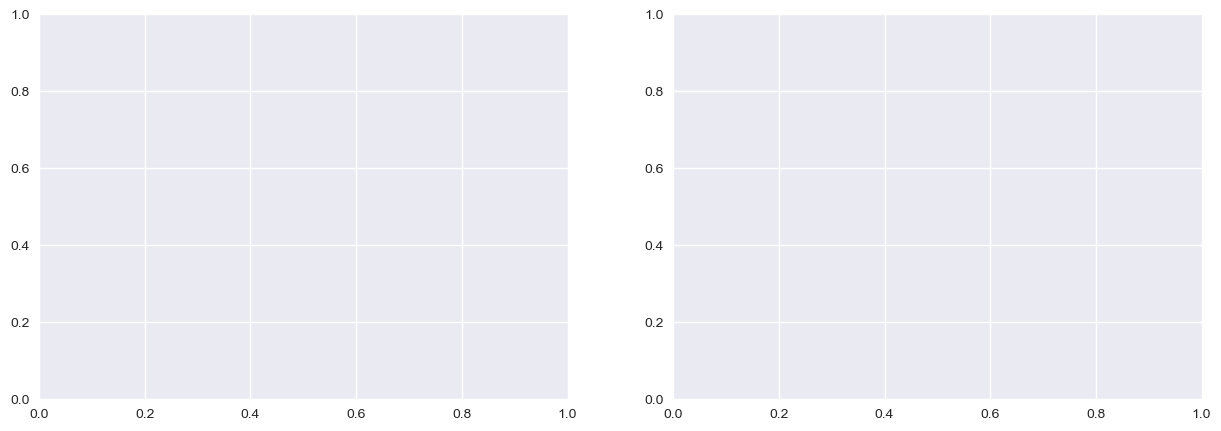

In [89]:
# Plotar o método do cotovelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico da Inércia

ax1.plot(k_range, inercias, 'bo-')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do Cotovelo')
ax1.grid(True)

# Gráfico do Silhouette Score
ax2.plot(k_range, silhouettes, 'ro-')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por k')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Plotar o método do cotovelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico da Inércia
ax1.plot(k_range, inercias, 'bo-')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do Cotovelo')
ax1.grid(True)

# Gráfico do Silhouette Score
ax2.plot(k_range, silhouettes, 'ro-')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por k')
ax2.grid(True)

plt.tight_layout()
plt.show()

### 4.2 Aplicação do K-Means com k Ótimo

Com base no método do cotovelo e no silhouette score, selecionamos o número ótimo de clusters e aplicamos o algoritmo K-Means.

In [ ]:
# Selecionar o número ótimo de clusters (ajuste conforme necessário)
k_otimo = 4  # Este valor pode ser ajustado com base nos gráficos acima
print(f"Número de clusters selecionado: {k_otimo}")

# Aplicar K-Means com k ótimo
kmeans_final = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_scaled)

# Adicionar os clusters ao dataframe original
df_clustering['cluster'] = clusters
df_ano['cluster'] = clusters

print(f"\nK-Means aplicado com sucesso!")
print(f"Inércia final: {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score final: {silhouette_score(df_scaled, clusters):.4f}")

### 4.3 Análise dos Clusters Formados

Analisamos as características de cada cluster para entender os padrões econômicos identificados.

In [ ]:
# Contagem de municípios por cluster
print("Distribuição de municípios por cluster:")
print(df_clustering['cluster'].value_counts().sort_index())

In [ ]:
# Estatísticas descritivas por cluster
print("\nEstatísticas descritivas por cluster:")
for cluster in sorted(df_clustering['cluster'].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(df_clustering[df_clustering['cluster'] == cluster][variaveis_clustering].describe())

In [ ]:
# Médias por cluster
medias_cluster = df_clustering.groupby('cluster')[variaveis_clustering].mean()
print("Médias das variáveis por cluster:")
print(medias_cluster)

## 5. Visualização dos Resultados

### 5.1 Visualização 2D com PCA

Como temos mais de 2 variáveis, usamos PCA (Principal Component Analysis) para reduzir a dimensionalidade e visualizar os clusters em 2D.

In [ ]:
from sklearn.decomposition import PCA

# Aplicar PCA para reduzir para 2 dimensões
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Criar DataFrame com os componentes principais
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters

# Plotar os clusters
plt.figure(figsize=(10, 8))
for cluster in sorted(df_pca['cluster'].unique()):
    plt.scatter(df_pca[df_pca['cluster'] == cluster]['PC1'],
                df_pca[df_pca['cluster'] == cluster]['PC2'],
                label=f'Cluster {cluster}', alpha=0.6, s=50)

plt.xlabel('Primeiro Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.title('Visualização dos Clusters com PCA')
plt.legend()
plt.grid(True)
plt.show()

### 5.2 Boxplots por Cluster

Visualizamos a distribuição das variáveis em cada cluster usando boxplots.

In [ ]:
# Criar boxplots para cada variável
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(variaveis_clustering):
    sns.boxplot(data=df_clustering, x='cluster', y=var, ax=axes[i])
    axes[i].set_title(f'Distribuição de {var} por Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(var)

# Remover o último subplot vazio
axes[-1].remove()

plt.tight_layout()
plt.show()

### 5.3 Heatmap das Médias por Cluster

Heatmap para visualizar as características médias de cada cluster.

In [ ]:
# Normalizar as médias para melhor visualização no heatmap
medias_cluster_norm = (medias_cluster - medias_cluster.min()) / (medias_cluster.max() - medias_cluster.min())

# Criar heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(medias_cluster_norm, annot=True, cmap='YlOrRd', fmt='.2f',
            xticklabels=variaveis_clustering, yticklabels=[f'Cluster {i}' for i in range(k_otimo)])
plt.title('Heatmap das Médias Normalizadas por Cluster')
plt.tight_layout()
plt.show()

## 6. Interpretação dos Clusters

Com base nas análises realizadas, podemos interpretar os clusters formados:

In [ ]:
# Exibir interpretação dos clusters
print("Interpretação dos Clusters:")
print("="*50)

for cluster in sorted(medias_cluster.index):
    print(f"\nCluster {cluster}:")
    print(f"  - Número de municípios: {len(df_clustering[df_clustering['cluster'] == cluster])}")
    print(f"  - PIB médio: R$ {medias_cluster.loc[cluster, 'pib']:,.2f}")
    print(f"  - VA Agropecuário médio: R$ {medias_cluster.loc[cluster, 'va_agropecuaria']:,.2f}")
    print(f"  - VA Indústria médio: R$ {medias_cluster.loc[cluster, 'va_industria']:,.2f}")
    print(f"  - VA Serviços médio: R$ {medias_cluster.loc[cluster, 'va_servicos']:,.2f}")
    print(f"  - VA ADESPSS médio: R$ {medias_cluster.loc[cluster, 'va_adespss']:,.2f}")

Interpretação dos Clusters:


NameError: name 'medias_cluster' is not defined

## 7. Conclusão

Nesta análise, implementamos o algoritmo K-Means para agrupar municípios brasileiros com base em suas características econômicas (PIB e valores adicionados por setor). Os principais passos realizados foram:

1. **Carregamento e exploração dos dados**: Analisamos a estrutura do dataset e identificamos as variáveis disponíveis.
2. **Pré-processamento**: Selecionamos um ano específico para análise, escolhemos as variáveis relevantes, tratamos valores ausentes e padronizamos os dados.
3. **Determinação do número de clusters**: Utilizamos o método do cotovelo e o silhouette score para determinar o número ótimo de clusters.
4. **Aplicação do K-Means**: Implementamos o algoritmo e geramos os clusters.
5. **Análise e visualização**: Interpretamos os resultados através de estatísticas descritivas e visualizações gráficas.

Os clusters formados permitem identificar grupos de municípios com perfis econômicos semelhantes, o que pode ser útil para políticas públicas direcionadas e análise regional.